In [ ]:
T_MIN=-4
T_MAX=4
N=4001
import numpy as np
def make_axis_and_signal():
  t = np.linesapce(T_MIN,T_MAX,N)
 
  x = np.sin(2*np.pi*t)+0.5*np.sin(2*np.pi*t)
  return t, x

In [ ]:
def unit_step(n):
    if(n>=0): return 1
    else :return 0

def unit_step(n):
   return (n >= 0).astype(int)

In [ ]:
def gated_exponential(n, a):
    return (a ** n) * (n >= 0)

In [ ]:
def time_reverse(x):
    mid = (len(x) - 1) / 2.0
    xr = x.copy() # <-- bug
    i = 0
    while i <= mid:
        xr[i], xr[len(x)-1-i] = x[len(x)-1-i], x[i]
        i += 1
    return xr

In [ ]:
def affine_transform(t, x, a, b):
    """y(t) = x(a*t + b), zero outside the recorded window."""
    q = a * t + b y = np.zeros_like(t)
    inr = (q >= t[0]) & (q <= t[-1])
    y[inr]= np.interp(q[inr], t, x) 
    return y


In [ ]:
def interpolate_signal(t, x, q):
    idx_r= np.clip(np.searchsorted(t, q, side="left"), 1, len(t)-1)
    idx_l= idx_r- 1
    tL, tR= t[idx_l], t[idx_r]; xL, xR= x[idx_l], x[idx_r]
    w = np.where(tR != tL, (q- tL) / (tR- tL), 0.0)
    return xL + w*(xR- xL) # = 0.5*(xL+xR) exactly at a midpoint (the spec's rule)

def time_scale(t, x, k):
    q = t / k 
    y = np.zeros_like(t) 
    inr = (q >= t[0]) & (q <= t[-1])
    y[inr]= interpolate_signal(t, x, q[inr])
    return y

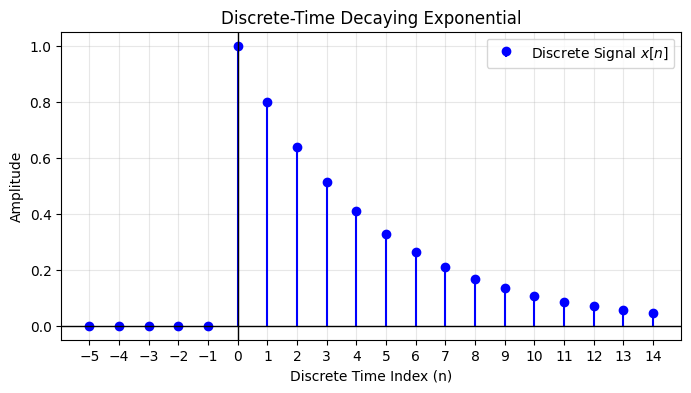

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate the discrete time vector (integer steps)
n = np.arange(-5, 15)

# 2. Generate the signal
# We use a boolean mask (n >= 0).astype(int) to simulate the unit step function u[n]
unit_step = (n >= 0).astype(int)
x = (0.8 ** n) * unit_step

# 3. Create the Canvas
plt.figure(figsize=(8, 4))

# 4. The Stem Plot Command
# - markerline, stemlines, baseline are the three visual objects returned.
# - We use basefmt=' ' to keep the chart clean.
markerline, stemlines, baseline = plt.stem(n, x, 
                                           linefmt='blue', 
                                           markerfmt='bo', # 'bo' = blue circles
                                           basefmt=' ',    # Hides the default red baseline
                                           label='Discrete Signal $x[n]$')

# 5. Structural Formatting
# We draw our own custom, subtle zero-axes to replace the ugly default baseline
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Ensure the x-axis ticks perfectly match our discrete integer points
plt.xticks(n) 

plt.title("Discrete-Time Decaying Exponential")
plt.xlabel("Discrete Time Index (n)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()